# Notebook 3: End-to-End Weather Forecast Email Service

This notebook combines the weather data pipeline and email sender service.

It accepts latitude, longitude, location name, and receiver email as input.  
When executed, it fetches current and forecast weather data, creates weather visualizations, builds an HTML weather report, and sends the report through email.

## Required Colab Secrets

Before running this notebook, add the following secrets in Google Colab:

- `OPENWEATHER_API_KEY`
- `BREVO_API_KEY`
- `SENDER_EMAIL`
- `SENDER_NAME`

Credentials are not hardcoded in this notebook for security reasons.

In [164]:
import os
import json
import base64
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import datetime
from matplotlib.collections import LineCollection
from google.colab import userdata

In [165]:
LATITUDE = 12.9716
LONGITUDE = 77.5946
LOCATION_NAME = "Bangalore, India"

TO_EMAIL = "arghya79@gmail.com"

UNITS = "metric"
LANGUAGE = "en"

In [166]:
OPENWEATHER_API_KEY = userdata.get("OPENWEATHER_API_KEY")
BREVO_API_KEY = userdata.get("BREVO_API_KEY")
SENDER_EMAIL = userdata.get("SENDER_EMAIL")
SENDER_NAME = userdata.get("SENDER_NAME")

In [167]:
secrets = {
    "OPENWEATHER_API_KEY": OPENWEATHER_API_KEY,
    "BREVO_API_KEY": BREVO_API_KEY,
    "SENDER_EMAIL": SENDER_EMAIL,
    "SENDER_NAME": SENDER_NAME
}

for key, value in secrets.items():
    if value is None:
        raise ValueError(f"{key} not found in Colab Secrets.")

In [168]:
OPENWEATHER_API_KEY = OPENWEATHER_API_KEY.strip()
BREVO_API_KEY = BREVO_API_KEY.strip()
SENDER_EMAIL = SENDER_EMAIL.strip()
SENDER_NAME = SENDER_NAME.strip()

print("All secrets loaded successfully.")

All secrets loaded successfully.


## Weather API Functions

The following functions fetch current weather and 5-day forecast data using latitude and longitude.

### Current Weather API Function

In [169]:
def fetch_current_weather(lat, lon, api_key, units="metric", lang="en"):
    url = "https://api.openweathermap.org/data/2.5/weather"

    params = {
        "lat": lat,
        "lon": lon,
        "appid": api_key,
        "units": units,
        "lang": lang
    }

    response = requests.get(url, params=params, timeout=20)

    if response.status_code != 200:
        raise Exception(f"Current Weather API Error {response.status_code}: {response.text}")

    return response.json()

### Forecast API Function

In [170]:
def fetch_forecast_weather(lat, lon, api_key, units="metric", lang="en"):
    url = "https://api.openweathermap.org/data/2.5/forecast"

    params = {
        "lat": lat,
        "lon": lon,
        "appid": api_key,
        "units": units,
        "lang": lang
    }

    response = requests.get(url, params=params, timeout=20)

    if response.status_code != 200:
        raise Exception(f"Forecast API Error {response.status_code}: {response.text}")

    return response.json()

### Fetching Weather Data

In [171]:
current_data = fetch_current_weather(
    lat=LATITUDE,
    lon=LONGITUDE,
    api_key=OPENWEATHER_API_KEY,
    units=UNITS,
    lang=LANGUAGE
)

forecast_data = fetch_forecast_weather(
    lat=LATITUDE,
    lon=LONGITUDE,
    api_key=OPENWEATHER_API_KEY,
    units=UNITS,
    lang=LANGUAGE
)

print("Weather data fetched successfully.")

Weather data fetched successfully.


In [172]:
raw_weather_response = {
    "current_weather": current_data,
    "forecast_weather": forecast_data
}

with open("raw_weather_response.json", "w") as file:
    json.dump(raw_weather_response, file, indent=4)

print("Raw weather response saved successfully.")

Raw weather response saved successfully.


### Local Time Modifier

In [173]:
timezone_offset = forecast_data["city"].get("timezone", 0)

def convert_to_local_datetime(timestamp):
    return datetime.utcfromtimestamp(timestamp + timezone_offset)

## Data Preparation

The raw API response is converted into structured dataframes for current weather, 3-hour forecast, and daily summary.

### Current Weather DataFrame

In [174]:
current_weather_summary = {
    "location": LOCATION_NAME,
    "timestamp": convert_to_local_datetime(current_data["dt"]),
    "temperature_celsius": current_data["main"].get("temp"),
    "feels_like_celsius": current_data["main"].get("feels_like"),
    "humidity_percent": current_data["main"].get("humidity"),
    "pressure_hpa": current_data["main"].get("pressure"),
    "wind_speed_mps": current_data["wind"].get("speed"),
    "cloudiness_percent": current_data["clouds"].get("all"),
    "weather_main": current_data["weather"][0].get("main"),
    "weather_description": current_data["weather"][0].get("description")
}

current_weather_df = pd.DataFrame([current_weather_summary])
current_weather_df

/tmp/ipykernel_14238/2905390378.py:4: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(timestamp + timezone_offset)


,location,timestamp,temperature_celsius,feels_like_celsius,humidity_percent,pressure_hpa,wind_speed_mps,cloudiness_percent,weather_main,weather_description
0,"Bangalore, India",2026-06-02 05:01:21,23.27,23.85,84,1012,4.92,40,Clouds,scattered clouds


### Forecast Dataframe

In [175]:
forecast_records = []

for item in forecast_data["list"]:
    forecast_records.append({
        "datetime": convert_to_local_datetime(item["dt"]),
        "temperature_celsius": item["main"].get("temp"),
        "feels_like_celsius": item["main"].get("feels_like"),
        "humidity_percent": item["main"].get("humidity"),
        "pressure_hpa": item["main"].get("pressure"),
        "wind_speed_mps": item["wind"].get("speed"),
        "cloudiness_percent": item["clouds"].get("all"),
        "pop_probability": item.get("pop", 0),
        "weather_main": item["weather"][0].get("main"),
        "weather_description": item["weather"][0].get("description")
    })

forecast_df = pd.DataFrame(forecast_records)
forecast_df.head()

/tmp/ipykernel_14238/2905390378.py:4: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(timestamp + timezone_offset)


,datetime,temperature_celsius,feels_like_celsius,humidity_percent,pressure_hpa,wind_speed_mps,cloudiness_percent,pop_probability,weather_main,weather_description
0,2026-06-02 05:30:00,23.14,23.73,85,1012,2.12,40,1.0,Rain,light rain
1,2026-06-02 08:30:00,22.97,23.46,82,1012,2.82,60,0.0,Clouds,broken clouds
2,2026-06-02 11:30:00,24.23,24.61,73,1013,2.50,79,0.0,Clouds,broken clouds
3,2026-06-02 14:30:00,28.99,29.53,49,1009,2.43,75,0.0,Clouds,broken clouds
4,2026-06-02 17:30:00,29.65,30.00,46,1008,2.17,58,0.0,Clouds,broken clouds


### Daily Summary Dataframe

In [176]:
forecast_df["date"] = forecast_df["datetime"].dt.date

daily_summary_df = forecast_df.groupby("date").agg(
    temp_min_celsius=("temperature_celsius", "min"),
    temp_max_celsius=("temperature_celsius", "max"),
    temp_avg_celsius=("temperature_celsius", "mean"),
    humidity_avg_percent=("humidity_percent", "mean"),
    wind_speed_avg_mps=("wind_speed_mps", "mean"),
    rain_probability_max=("pop_probability", "max"),
    cloudiness_avg_percent=("cloudiness_percent", "mean")
).reset_index()

daily_summary_df

,date,temp_min_celsius,temp_max_celsius,temp_avg_celsius,humidity_avg_percent,wind_speed_avg_mps,rain_probability_max,cloudiness_avg_percent
0,2026-06-02,22.97,29.65,25.995714,64.857143,2.61000,1.00,60.428571
1,2026-06-03,22.88,30.16,25.802500,61.875000,4.12125,1.00,74.250000
2,2026-06-04,21.33,28.89,24.841250,66.625000,4.93625,1.00,89.750000
3,2026-06-05,20.79,30.26,24.907500,62.500000,5.65000,0.20,60.125000
4,2026-06-06,20.71,31.10,24.920000,65.000000,5.53250,0.42,91.750000
5,2026-06-07,20.87,20.87,20.870000,84.000000,5.59000,0.00,6.000000


## Weather Visualizations

The following section generates professional forecast charts and saves them as PNG files.  
These charts are attached to the final weather report email.

In [177]:
os.makedirs("weather_charts", exist_ok=True)

print("Chart folder ready.")

Chart folder ready.


### Chart Styling Function

In [178]:
def apply_chart_style(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    ax.set_facecolor("#F8FAFC")
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.45)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="x", rotation=45)

### Time Axis Formatter

In [179]:
def format_time_axis(ax):
    locator = mdates.HourLocator(interval=12)
    formatter = mdates.DateFormatter("%d %b\n%I %p")

    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

### Gradient Line Chart Function

In [180]:
def plot_gradient_line(
    df,
    x_col,
    y_col,
    title,
    ylabel,
    save_path,
    cmap="coolwarm"
):
    x = mdates.date2num(df[x_col])
    y = df[y_col].values

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor("white")

    norm = plt.Normalize(y.min(), y.max())

    line_collection = LineCollection(
        segments,
        cmap=cmap,
        norm=norm,
        linewidth=3
    )

    line_collection.set_array(y)
    ax.add_collection(line_collection)

    ax.scatter(
        df[x_col],
        y,
        s=28,
        c=y,
        cmap=cmap,
        norm=norm,
        edgecolor="black",
        linewidth=0.4
    )

    ax.set_xlim(df[x_col].min(), df[x_col].max())
    ax.set_ylim(y.min() - 1, y.max() + 1)

    apply_chart_style(
        ax=ax,
        title=title,
        xlabel="Forecast Time",
        ylabel=ylabel
    )

    format_time_axis(ax)

    colorbar = fig.colorbar(line_collection, ax=ax, pad=0.02)
    colorbar.set_label(ylabel)

    max_idx = df[y_col].idxmax()
    min_idx = df[y_col].idxmin()

    ax.annotate(
        f"Max: {df.loc[max_idx, y_col]:.1f}",
        xy=(df.loc[max_idx, x_col], df.loc[max_idx, y_col]),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

    ax.annotate(
        f"Min: {df.loc[min_idx, y_col]:.1f}",
        xy=(df.loc[min_idx, x_col], df.loc[min_idx, y_col]),
        xytext=(0, -20),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

### Generating Forecast Charts

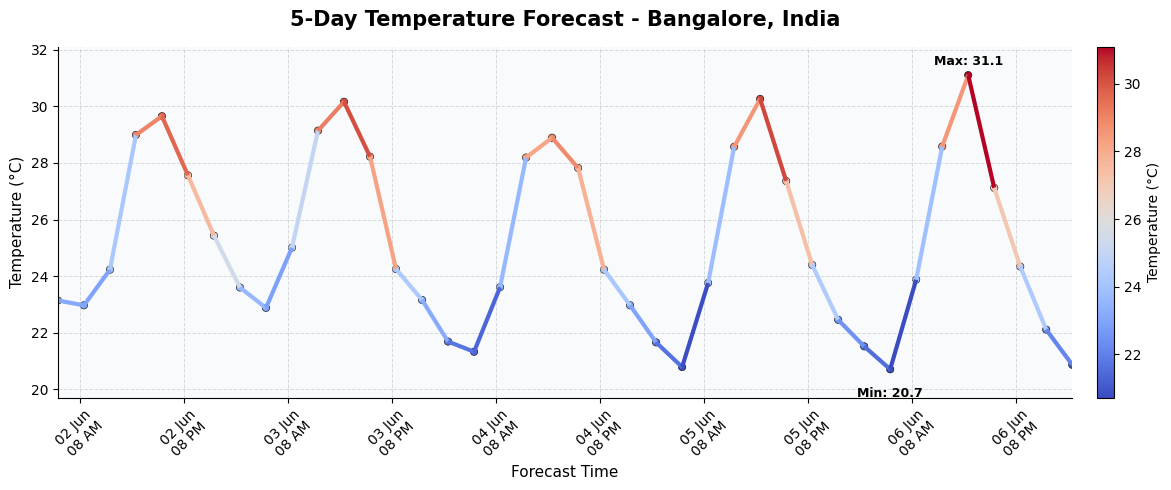

In [181]:
plot_gradient_line(
    df=forecast_df,
    x_col="datetime",
    y_col="temperature_celsius",
    title=f"5-Day Temperature Forecast - {LOCATION_NAME}",
    ylabel="Temperature (°C)",
    save_path="weather_charts/temperature_forecast.png",
    cmap="coolwarm"
)

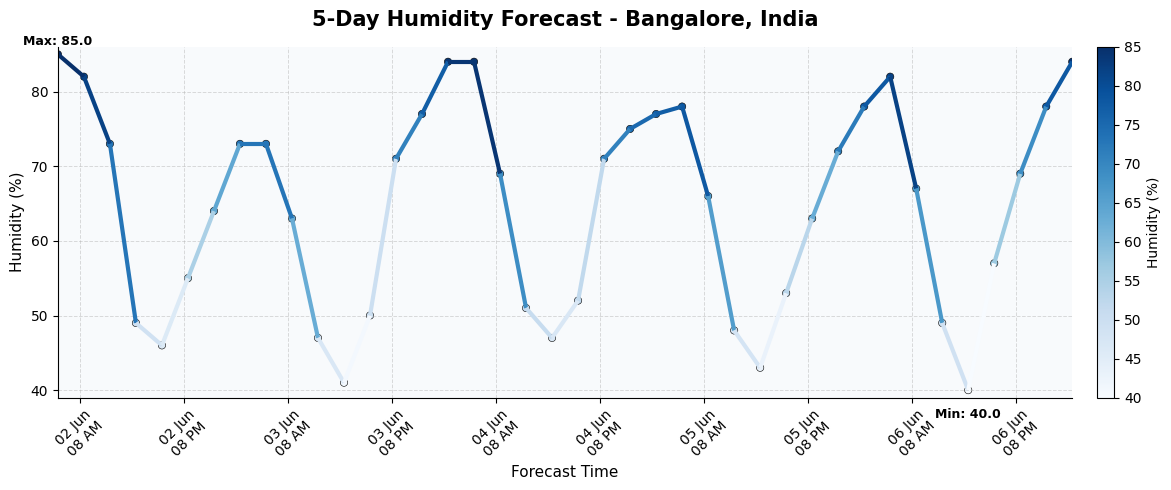

In [182]:
plot_gradient_line(
    df=forecast_df,
    x_col="datetime",
    y_col="humidity_percent",
    title=f"5-Day Humidity Forecast - {LOCATION_NAME}",
    ylabel="Humidity (%)",
    save_path="weather_charts/humidity_forecast.png",
    cmap="Blues"
)

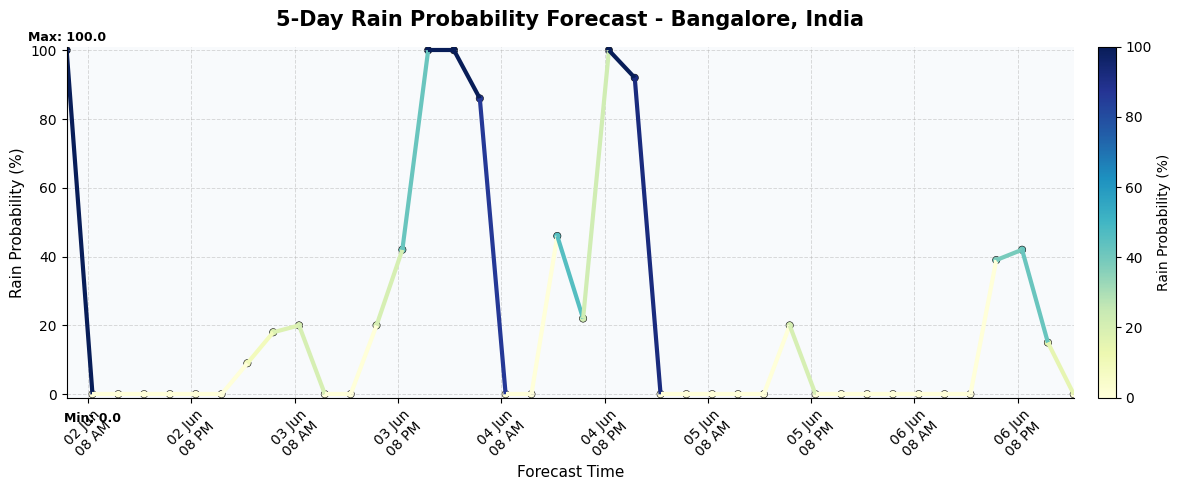

In [183]:
forecast_df["rain_probability_percent"] = forecast_df["pop_probability"] * 100

plot_gradient_line(
    df=forecast_df,
    x_col="datetime",
    y_col="rain_probability_percent",
    title=f"5-Day Rain Probability Forecast - {LOCATION_NAME}",
    ylabel="Rain Probability (%)",
    save_path="weather_charts/rain_probability_forecast.png",
    cmap="YlGnBu"
)

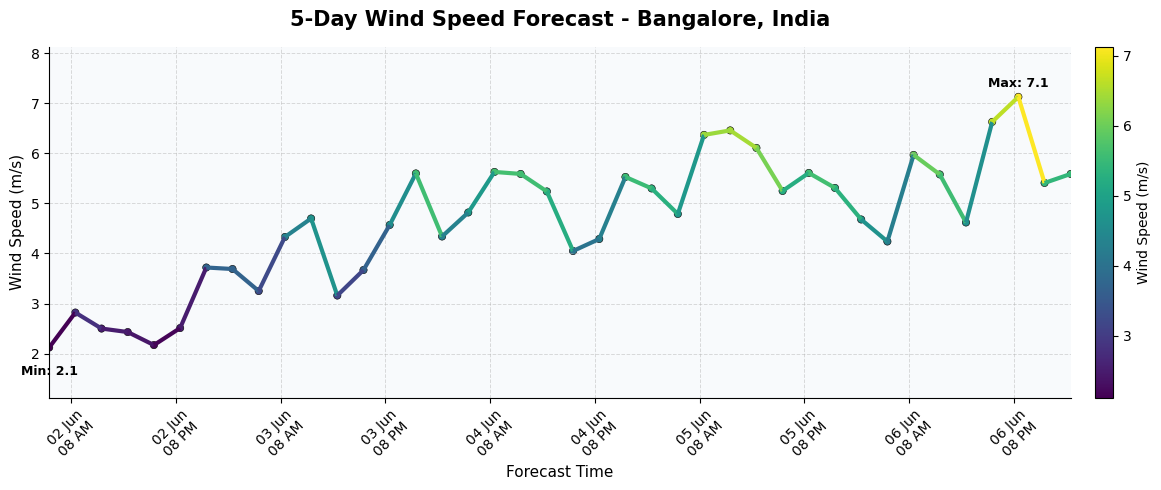

In [184]:
plot_gradient_line(
    df=forecast_df,
    x_col="datetime",
    y_col="wind_speed_mps",
    title=f"5-Day Wind Speed Forecast - {LOCATION_NAME}",
    ylabel="Wind Speed (m/s)",
    save_path="weather_charts/wind_speed_forecast.png",
    cmap="viridis"
)

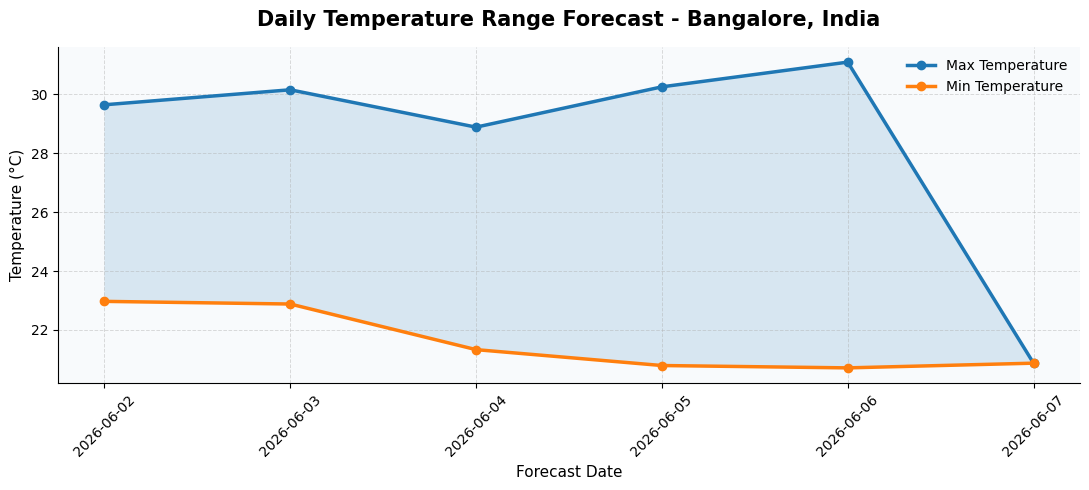

In [185]:
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8FAFC")

ax.plot(
    daily_summary_df["date"],
    daily_summary_df["temp_max_celsius"],
    marker="o",
    linewidth=2.5,
    label="Max Temperature"
)

ax.plot(
    daily_summary_df["date"],
    daily_summary_df["temp_min_celsius"],
    marker="o",
    linewidth=2.5,
    label="Min Temperature"
)

ax.fill_between(
    daily_summary_df["date"],
    daily_summary_df["temp_min_celsius"],
    daily_summary_df["temp_max_celsius"],
    alpha=0.15
)

apply_chart_style(
    ax=ax,
    title=f"Daily Temperature Range Forecast - {LOCATION_NAME}",
    xlabel="Forecast Date",
    ylabel="Temperature (°C)"
)

ax.legend(frameon=False)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("weather_charts/daily_min_max_temperature.png", dpi=300, bbox_inches="tight")
plt.show()

In [186]:
chart_files = [
    "weather_charts/temperature_forecast.png",
    "weather_charts/humidity_forecast.png",
    "weather_charts/rain_probability_forecast.png",
    "weather_charts/wind_speed_forecast.png",
    "weather_charts/daily_min_max_temperature.png"
]

for chart in chart_files:
    print(chart, "exists:", os.path.exists(chart))

weather_charts/temperature_forecast.png exists: True
weather_charts/humidity_forecast.png exists: True
weather_charts/rain_probability_forecast.png exists: True
weather_charts/wind_speed_forecast.png exists: True
weather_charts/daily_min_max_temperature.png exists: True


## HTML Weather Report

The following section creates a formatted HTML weather report using current weather and daily forecast summary.

### Helper Function for Weather Label

In [187]:
def format_value(value, suffix="", decimals=1):
    if pd.isna(value):
        return "N/A"

    if isinstance(value, (int, float)):
        return f"{value:.{decimals}f}{suffix}"

    return str(value)

### Build daily Forecast HTML Rows

In [188]:
daily_rows_html = ""

for _, row in daily_summary_df.iterrows():
    daily_rows_html += f"""
    <tr>
        <td style="padding:10px; border:1px solid #e5e7eb;">{row['date']}</td>
        <td style="padding:10px; border:1px solid #e5e7eb;">{row['temp_min_celsius']:.1f}°C</td>
        <td style="padding:10px; border:1px solid #e5e7eb;">{row['temp_max_celsius']:.1f}°C</td>
        <td style="padding:10px; border:1px solid #e5e7eb;">{row['temp_avg_celsius']:.1f}°C</td>
        <td style="padding:10px; border:1px solid #e5e7eb;">{row['humidity_avg_percent']:.1f}%</td>
        <td style="padding:10px; border:1px solid #e5e7eb;">{row['rain_probability_max'] * 100:.1f}%</td>
    </tr>
    """

### Creating HTML E-Mail Body

In [189]:
current = current_weather_summary

html_weather_report = f"""
<html>
  <body style="margin:0; padding:0; background-color:#f4f7fb; font-family:Arial, sans-serif;">
    <div style="max-width:850px; margin:30px auto; background-color:#ffffff; border-radius:14px; padding:28px; border:1px solid #e5e7eb;">

      <h2 style="color:#1f4e79; margin-bottom:6px;">
        Daily Weather Forecast Report
      </h2>

      <p style="color:#6b7280; margin-top:0;">
        Location: <b>{LOCATION_NAME}</b><br>
        Generated at: <b>{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}</b>
      </p>

      <div style="background-color:#eff6ff; border-left:5px solid #2563eb; padding:16px; margin:22px 0; border-radius:8px;">
        <h3 style="margin-top:0; color:#1e3a8a;">Current Weather Summary</h3>
        <p style="font-size:15px; color:#374151; line-height:1.7;">
          Current condition is <b>{current['weather_description'].title()}</b>.
          Temperature is <b>{current['temperature_celsius']}°C</b>, feels like
          <b>{current['feels_like_celsius']}°C</b>. Humidity is
          <b>{current['humidity_percent']}%</b> with wind speed of
          <b>{current['wind_speed_mps']} m/s</b>.
        </p>
      </div>

      <h3 style="color:#111827;">Current Weather Details</h3>

      <table style="border-collapse:collapse; width:100%; margin-top:12px; font-size:14px;">
        <tr>
          <td style="padding:10px; border:1px solid #e5e7eb; background-color:#f9fafb;"><b>Temperature</b></td>
          <td style="padding:10px; border:1px solid #e5e7eb;">{current['temperature_celsius']}°C</td>
        </tr>
        <tr>
          <td style="padding:10px; border:1px solid #e5e7eb; background-color:#f9fafb;"><b>Feels Like</b></td>
          <td style="padding:10px; border:1px solid #e5e7eb;">{current['feels_like_celsius']}°C</td>
        </tr>
        <tr>
          <td style="padding:10px; border:1px solid #e5e7eb; background-color:#f9fafb;"><b>Humidity</b></td>
          <td style="padding:10px; border:1px solid #e5e7eb;">{current['humidity_percent']}%</td>
        </tr>
        <tr>
          <td style="padding:10px; border:1px solid #e5e7eb; background-color:#f9fafb;"><b>Wind Speed</b></td>
          <td style="padding:10px; border:1px solid #e5e7eb;">{current['wind_speed_mps']} m/s</td>
        </tr>
        <tr>
          <td style="padding:10px; border:1px solid #e5e7eb; background-color:#f9fafb;"><b>Cloudiness</b></td>
          <td style="padding:10px; border:1px solid #e5e7eb;">{current['cloudiness_percent']}%</td>
        </tr>
      </table>

      <h3 style="color:#111827; margin-top:28px;">Daily Forecast Summary</h3>

      <table style="border-collapse:collapse; width:100%; margin-top:12px; font-size:13px;">
        <tr style="background-color:#1f4e79; color:#ffffff;">
          <th style="padding:10px; border:1px solid #e5e7eb;">Date</th>
          <th style="padding:10px; border:1px solid #e5e7eb;">Min Temp</th>
          <th style="padding:10px; border:1px solid #e5e7eb;">Max Temp</th>
          <th style="padding:10px; border:1px solid #e5e7eb;">Avg Temp</th>
          <th style="padding:10px; border:1px solid #e5e7eb;">Avg Humidity</th>
          <th style="padding:10px; border:1px solid #e5e7eb;">Max Rain Probability</th>
        </tr>
        {daily_rows_html}
      </table>

      <p style="margin-top:26px; color:#374151; font-size:14px; line-height:1.6;">
        Forecast charts are attached with this email for visual analysis.
      </p>

      <p style="margin-top:24px; color:#374151; font-size:15px;">
        Regards,<br>
        <b>Weather Forecast Email Service</b>
      </p>

    </div>
  </body>
</html>
"""

In [190]:
with open("weather_email_report.html", "w", encoding="utf-8") as file:
    file.write(html_weather_report)

print("HTML weather email report saved successfully.")

HTML weather email report saved successfully.


## Send Weather Report Email

The final report is sent through the Brevo Transactional Email API.  
The weather charts are attached as PNG files.

### Encoding Attachments

In [191]:
def encode_file_to_base64(file_path):
    with open(file_path, "rb") as file:
        encoded_content = base64.b64encode(file.read()).decode("utf-8")
    return encoded_content

### Building Attachment Payload

In [192]:
attachments = []

for chart_path in chart_files:
    if os.path.exists(chart_path):
        attachments.append({
            "name": os.path.basename(chart_path),
            "content": encode_file_to_base64(chart_path)
        })

print(f"Total attachments prepared: {len(attachments)}")

Total attachments prepared: 5


### Brevo E-Mail Function

In [193]:
def send_weather_email_with_brevo(
    to_email,
    subject,
    html_body,
    sender_email,
    sender_name,
    brevo_api_key,
    attachments=None
):
    url = "https://api.brevo.com/v3/smtp/email"

    headers = {
        "accept": "application/json",
        "api-key": brevo_api_key,
        "content-type": "application/json"
    }

    payload = {
        "sender": {
            "name": sender_name,
            "email": sender_email
        },
        "to": [
            {
                "email": to_email
            }
        ],
        "subject": subject,
        "htmlContent": html_body,
        "textContent": "This email contains a weather forecast report. Please view it in an HTML-supported email client."
    }

    if attachments:
        payload["attachment"] = attachments

    response = requests.post(url, headers=headers, json=payload, timeout=30)

    if response.status_code not in [200, 201, 202]:
        raise Exception(
            f"Email sending failed. Status Code: {response.status_code}, Response: {response.text}"
        )

    return response.json()

### Sending Final Weather Report

In [194]:
EMAIL_SUBJECT = f"Daily Weather Forecast Report - {LOCATION_NAME}"

email_response = send_weather_email_with_brevo(
    to_email=TO_EMAIL,
    subject=EMAIL_SUBJECT,
    html_body=html_weather_report,
    sender_email=SENDER_EMAIL,
    sender_name=SENDER_NAME,
    brevo_api_key=BREVO_API_KEY,
    attachments=attachments
)

print("Weather report email sent successfully.")
print(email_response)

Weather report email sent successfully.
{'messageId': '<202606012336.68745879583@smtp-relay.mailin.fr>'}


### Final Success Summary

In [195]:
print("End-to-end weather forecast email service completed successfully.")
print(f"Location: {LOCATION_NAME}")
print(f"Receiver: {TO_EMAIL}")
print(f"Charts attached: {len(attachments)}")
print(f"Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

End-to-end weather forecast email service completed successfully.
Location: Bangalore, India
Receiver: arghya79@gmail.com
Charts attached: 5
Generated at: 2026-06-01 23:36:23


## Final Output

When this notebook is executed successfully:

- Current weather data is fetched
- 5-day forecast data is fetched
- Weather charts are generated
- HTML weather report is created
- Weather report email is sent to the configured receiver email
- Forecast charts are attached to the email

## Production Design Note

This notebook demonstrates the complete workflow in Google Colab.

For production, this workflow can be moved to a serverless architecture:

- AWS Lambda to run the Python weather-email script
- Amazon EventBridge Scheduler to trigger the Lambda function daily
- AWS Secrets Manager to store API keys securely
- Amazon SES for production-grade email delivery
- Amazon CloudWatch for logging and monitoring

The notebook version is suitable for demonstration, while the serverless design is suitable for automated daily execution.